In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
plt.style.use("dark_background") 

## Fase 2: Comprensión de los Datos (Data Understanding)


In [14]:
## abrir el dataset
df = pd.read_csv('student_dropout_dataset.csv')
df.head()

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass,label_name
0,STU00001,26,Alexandria,2024-01-13,0,3,5,0.3571,5.29,10,5,0.1064,0,0,active
1,STU00002,23,Amman,2024-05-05,0,6,0,0.0000,0.84,7,0,0.6627,1,2,dropped
2,STU00003,17,Dubai,2024-03-12,0,3,1,0.0435,1.79,36,0,0.7299,1,2,dropped
3,STU00004,23,Alexandria,2024-12-12,0,6,13,0.4396,0.78,9,0,0.5315,1,1,at-risk
4,STU00005,20,Baghdad,2024-02-14,0,5,5,0.2078,0.92,11,0,0.7904,1,2,dropped


In [15]:
## eliminamso las columnas que no nescesitamos 
df = df.drop(columns=[
    'student_id',
    'dropout_score',
    'label_multiclass',
    'label_name', 
    'region' , 
    'enroll_date'
])
df = df.rename(columns={'label':'target'})

In [16]:
## columnas  y tipos de datos
df.dtypes

age                         int64
exam_season                 int64
courses_enrolled            int64
completed_assignments       int64
completion_rate           float64
login_frequency           float64
last_activity_days_ago      int64
forum_posts_count           int64
target                      int64
dtype: object

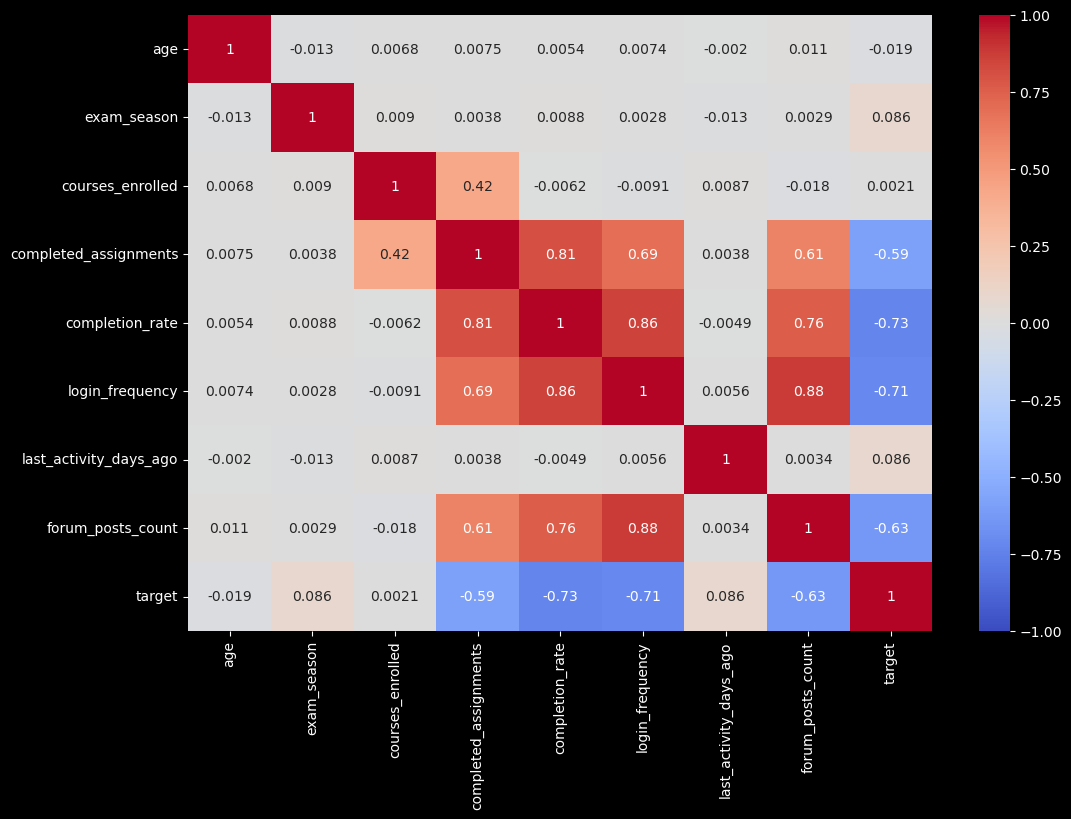

In [17]:
## matris de correlacion de las caracteristicas 
corre = df[df.select_dtypes(include='number').columns].corr()
plt.figure(figsize=(12  , 8))
sns.heatmap(corre , annot=True  , vmax=1   , vmin=-1 ,  cmap="coolwarm" )
plt.show()

In [18]:
df.describe()

,age,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,target
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000
mean,23.736600,0.094000,3.999400,5.188400,0.260985,3.453820,9.3564,4.212200,0.659200
std,4.583211,0.291858,1.997348,6.109466,0.249010,3.248316,9.4361,4.270131,0.474026
min,17.000000,0.000000,1.000000,0.000000,0.000000,0.100000,1.0000,0.000000,0.000000
25%,20.000000,0.000000,2.000000,1.000000,0.053900,0.980000,2.0000,1.000000,0.000000
50%,24.000000,0.000000,4.000000,3.000000,0.206700,2.440000,6.0000,3.000000,1.000000
75%,27.000000,0.000000,6.000000,7.000000,0.389025,4.942500,13.0000,6.000000,1.000000
max,40.000000,1.000000,7.000000,35.000000,1.000000,14.000000,70.0000,24.000000,1.000000


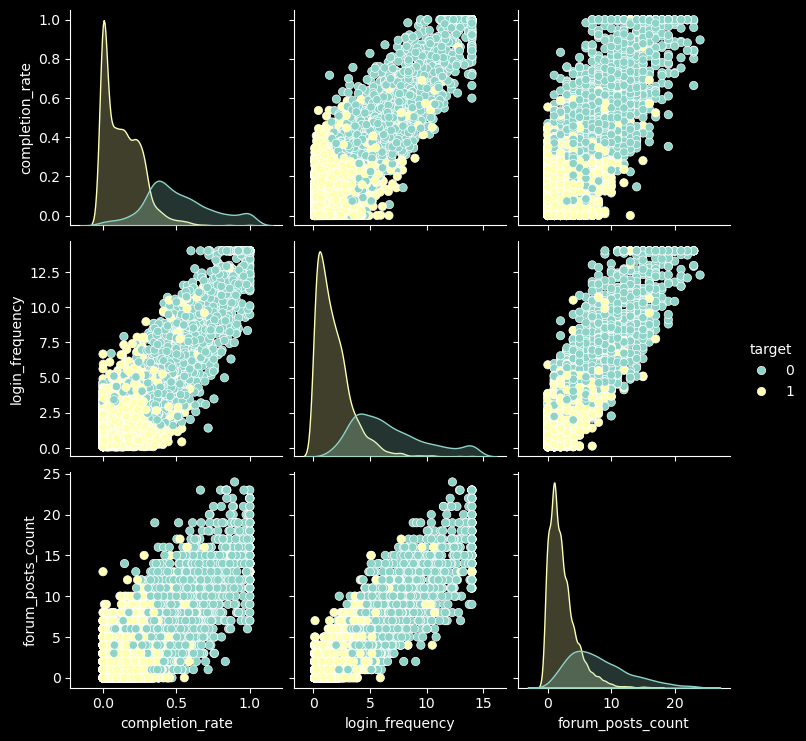

In [19]:
##  relaciones bivariadas entre las variables numéricas del dataset.
cols = ['completion_rate','login_frequency','forum_posts_count','target']
sns.pairplot(df[cols], hue='target')

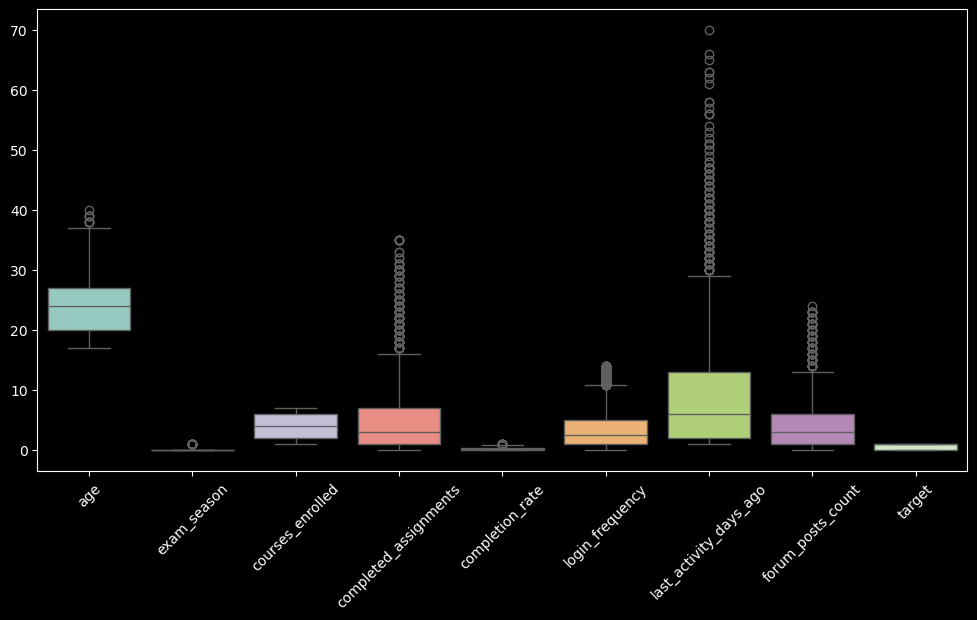

In [20]:
## deteccion de valore atipicos com box plot
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=45)
plt.show()

## Fase 3: Preparación de los Datos (Data Preparation)


In [21]:
### ver si hay datos nulos
missing_info = pd.DataFrame({
    "nulos": df.isnull().sum(),
     "no_nulos": df.notnull().sum(),
     "porcentaje_nulos": df.isnull().mean() * 100,
    "porcentaje_no_nulos": df.notnull().mean() * 100
})
missing_info

,nulos,no_nulos,porcentaje_nulos,porcentaje_no_nulos
age,0,5000,0.0,100.0
exam_season,0,5000,0.0,100.0
courses_enrolled,0,5000,0.0,100.0
completed_assignments,0,5000,0.0,100.0
completion_rate,0,5000,0.0,100.0
login_frequency,0,5000,0.0,100.0
last_activity_days_ago,0,5000,0.0,100.0
forum_posts_count,0,5000,0.0,100.0
target,0,5000,0.0,100.0


In [22]:
## imputacion de datos 
def imputacion (name_column):
    mean = df[name_column].mean()
    df[name_column].replace(np.nan , mean , inplace=True)
## esta funciona solo funciona para valores columnas numericas en caso que sean categoricas se aplica la moda

In [23]:
##seleccion de variables independientes y variable objetivo
columnas = ['completion_rate',
        'login_frequency',
        'forum_posts_count',
        'completed_assignments',
        'last_activity_days_ago' ]

x_data = df[columnas]

y_data = df['target']

In [24]:
## separa los datos en trin y test 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    x_data, y_data, test_size=0.2, stratify=y_data, random_state=42
)

## estandarisar los datos 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
df['target'].value_counts(normalize=True)

target
1    0.6592
0    0.3408
Name: proportion, dtype: float64

## Fase 4: Modelado (Modeling) Regrecion Logistica


In [43]:
## MODELO DE REGRECION LOGISTICA 
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Fase 5: Evaluación (Evaluation)


In [30]:
## predicciones 
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

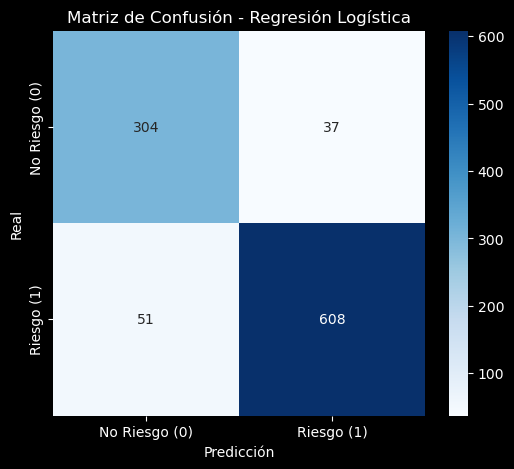

In [32]:
## Matriz de Confusión
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Riesgo (0)', 'Riesgo (1)'],
            yticklabels=['No Riesgo (0)', 'Riesgo (1)'] )

plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

In [45]:
## recall
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.9226100151745068


In [46]:
## metricas
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87       341
           1       0.94      0.92      0.93       659

    accuracy                           0.91      1000
   macro avg       0.90      0.91      0.90      1000
weighted avg       0.91      0.91      0.91      1000



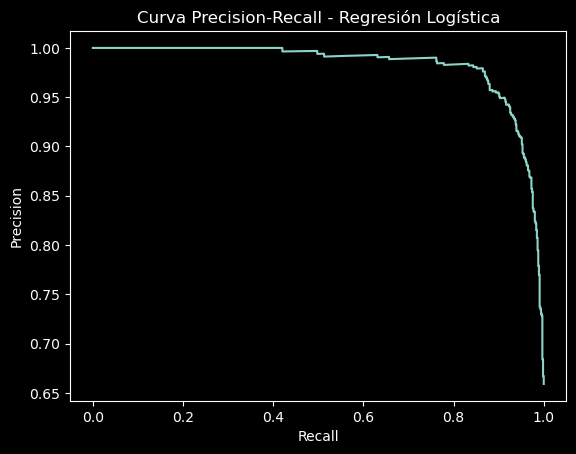

In [47]:
## Curva Precision-Recall
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall_vals, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall_vals, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Regresión Logística")
plt.show()